In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from scipy.stats import pearsonr, entropy
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt
import numpy as np

# os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3"

/home/zhangyong203/miniconda3/envs/prob/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load model

torch.mps.empty_cache() if torch.backends.mps.is_available() else None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# model_name = "Qwen/Qwen3-1.7B"
# model_name = "meta-llama/Llama-3.2-1B-Instruct"
model_name = "Qwen/Qwen3-1.7B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    output_hidden_states=True,
    output_attentions=True,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="eager",  # Set this during model initialization
)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.22it/s]


Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwe

In [ ]:
# Load dataset

import json

class Sample:
    def __init__(self, prompt, label):
        self.prompt = prompt
#         self.response = response
        self.label = label  # 1=high, 0=low

dataset = []
# Load the pre-processed good/bad samples from your new file
with open('Meta-Llama-3-8B-Instruct_math_roscoe5dim_probing.json', 'r') as f:
    all_data = json.load(f)
#     for dim in ['semantic_consistency', 'logicality', 'informativeness', 'fluency', 'factuality']:
    for sample in all_data['factuality']:       # You can change the dimension here, from 5 dimensions above
        dataset.append(Sample(prompt=sample['eval_prompt'], label=sample['score']))

print(len(dataset))
labels = np.array([ex.label for ex in dataset])

from collections import Counter
Counter([sample.label for sample in dataset])

170


Counter({2: 34, 4: 34, 3: 34, 5: 34, 1: 34})

#### extract features

In [4]:
from tqdm import tqdm

def extract_batch_reps(batch: list[Sample]):
    """Returns dict of arrays: reps[layer]['mean'|'last'|'min'|'max'|'concat'], attn_entropy[layer][head]"""
    inputs = tokenizer(
        [ex.prompt for ex in batch],
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(model.device)
    
    with torch.no_grad():
        out = model(
            **inputs,
            output_hidden_states=True,
            output_attentions=True,
        )

    hidden = out.hidden_states             # tuple of (B, S, H) per layer
    attentions = out.attentions            # tuple of (B, heads, S, S) per layer

    reps = {}
    attn_entropy = {}
    
    # ignore the first embedding layer in hidden layers
    for layer_idx, h in enumerate(hidden[1:]):
        # 1) mean-pooled
        mean_pooled = h.mean(dim=1).cpu().detach().numpy()       # (B, H)
        
        # 2) last-token (EOS) pooled
        seq_lens = (inputs.attention_mask.sum(dim=1) - 1).cpu()
        last_tokens = torch.stack([
            h[i, seq_lens[i], :]
            for i in range(h.size(0))
        ]).cpu().detach().numpy()                                # (B, H)
        
        # 3) min-pooled
        min_pooled = h.min(dim=1)[0].cpu().detach().numpy()     # (B, H)
        
        # 4) max-pooled
        max_pooled = h.max(dim=1)[0].cpu().detach().numpy()     # (B, H)
        
        # 5) concatenation of min, max, mean
        concat_pooled = np.concatenate([min_pooled, max_pooled, mean_pooled], axis=1)  # (B, 3*H)
        
        reps[layer_idx] = {
            "mean": mean_pooled, 
            "last": last_tokens,
            "min": min_pooled,
            "max": max_pooled,
            "concat": concat_pooled
        }
        
        # Attention head entropy per example
        # average entropy across source tokens for each head
        A = attentions[layer_idx]      # (B, heads, S, S)
        # compute entropy over S distribution for each head and each example, then mean
        # Only compute entropy for non-zero attention weights
        mask = A > 0
        log_A = torch.where(mask, torch.log(A), torch.zeros_like(A))
        ent = - (A * log_A).sum(dim=-1).mean(dim=-1)
        # ent = - (A * torch.log(A + 1e-12)).sum(dim=-1).mean(dim=-1)  # (B, heads)
        attn_entropy[layer_idx] = ent.cpu().detach().numpy()   # (B, heads)
    
    return reps, attn_entropy

In [ ]:
# Run in batches, cache to disk or memory to avoid recompute
all_reps, all_attn = {}, {}
batch_size = 1
for i in tqdm(range(0, len(dataset), batch_size)):
    batch = dataset[i : i + batch_size]
    reps, ent = extract_batch_reps(batch)
    for l in reps:
        if l not in all_reps: 
            all_reps[l] = {"mean": [], "last": [], "min": [], "max": [], "concat": []}
        for pool_method in ["mean", "last", "min", "max", "concat"]:
            all_reps[l][pool_method].append(reps[l][pool_method])
        all_attn.setdefault(l, []).append(ent[l])

# Stack per layer/pool
for l in all_reps:
    all_reps[l]["mean"] = np.vstack(all_reps[l]["mean"])
    all_reps[l]["last"] = np.vstack(all_reps[l]["last"])
    all_reps[l]["min"] = np.vstack(all_reps[l]["min"])
    all_reps[l]["max"] = np.vstack(all_reps[l]["max"])
    all_reps[l]["concat"] = np.vstack(all_reps[l]["concat"])  # (N, 3*H)
    all_attn[l] = np.vstack(all_attn[l])  # shape (N, heads)

labels = np.array([ex.label for ex in dataset])

100%|██████████| 170/170 [00:14<00:00, 11.71it/s]


#### save all_reps and all_attn first, then load them (optional)

In [ ]:
# Save all_reps
np.savez('math_prob_reps.npz', **{f"{l}_{k}": v for l, d in all_reps.items() for k, v in d.items()})

# Save all_attn
np.savez('math_prob_attn.npz', **{f"{l}_attn": v for l, v in all_attn.items()})

# Load all_reps
loaded_reps = np.load('gsm8k_prob_reps.npz')
all_reps = {}
for key in loaded_reps:
    l, kind = key.split('_')
    l = int(l)
    if l not in all_reps:
        all_reps[l] = {}
    all_reps[l][kind] = loaded_reps[key]

# Load all_attn
loaded_attn = np.load('gsm8k_prob_attn.npz')
all_attn = {int(k.split('_')[0]): loaded_attn[k] for k in loaded_attn}

#### layer probing

Processing 28 layers...
Layer 0...
Layer 1...
Layer 2...
Layer 3...
Layer 4...
Layer 5...
Layer 6...
Layer 7...
Layer 8...
Layer 9...
Layer 10...
Layer 11...
Layer 12...
Layer 13...
Layer 14...
Layer 15...
Layer 16...
Layer 17...
Layer 18...
Layer 19...
Layer 20...
Layer 21...
Layer 22...
Layer 23...
Layer 24...
Layer 25...
Layer 26...
Layer 27...


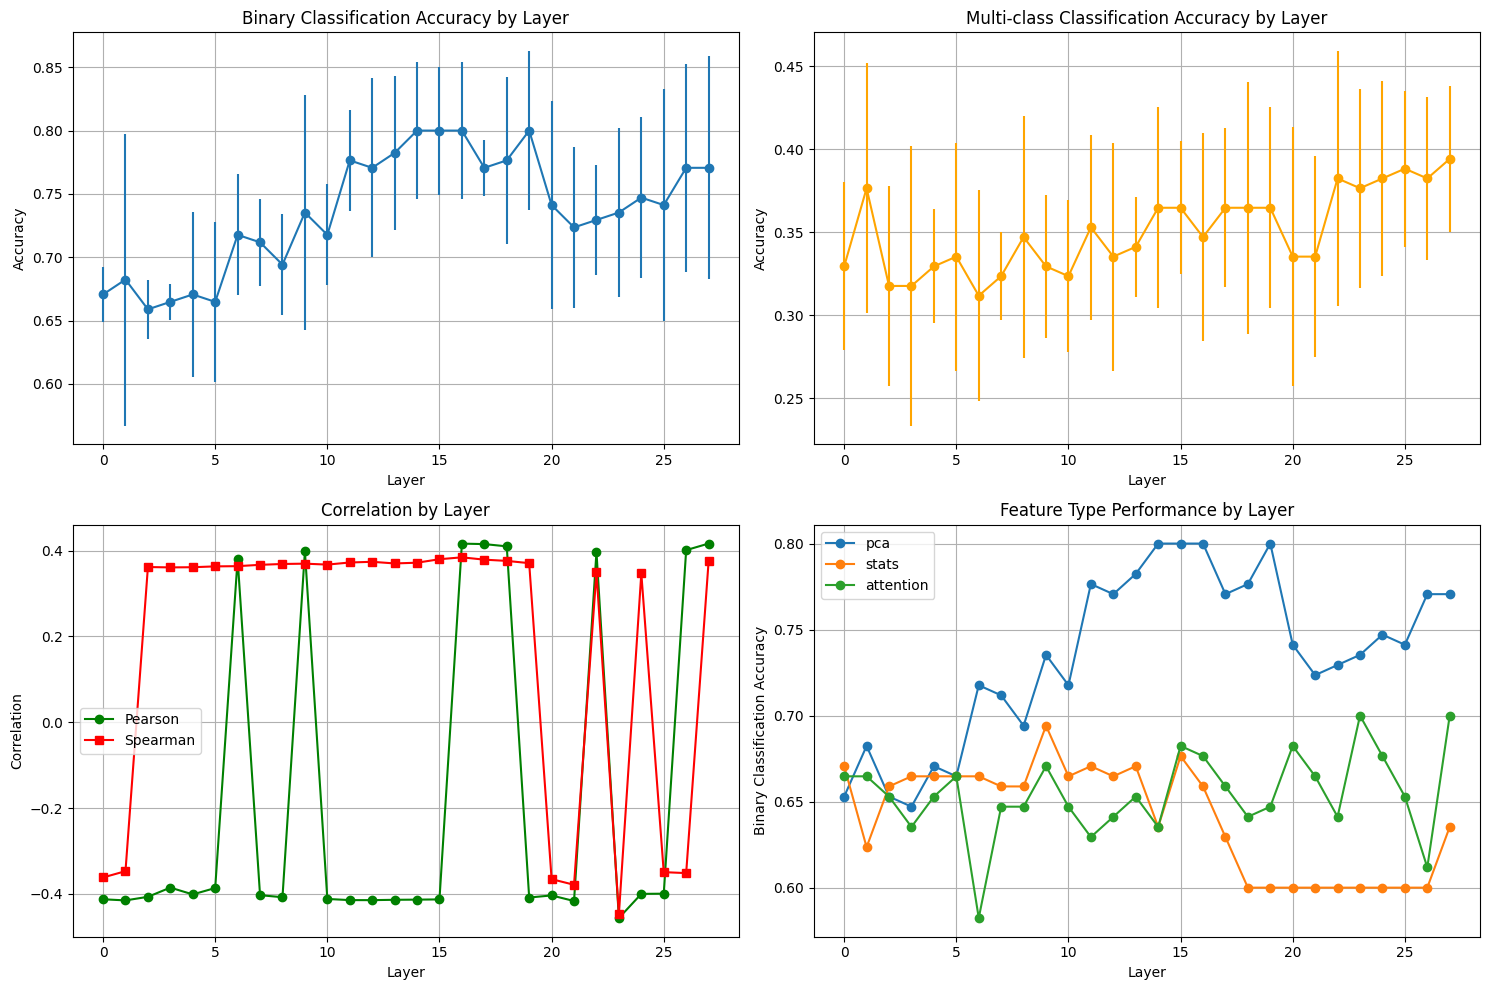

Top performing layer-feature combinations by binary acc:
Rank Layer  Pool   Feature    Binary Acc   Multi Acc    Spearman r  
--------------------------------------------------------------------------------
1    14     mean   pca        0.800±0.054 0.365±0.061 0.372
2    15     mean   pca        0.800±0.051 0.347±0.075 0.380
3    16     mean   pca        0.800±0.054 0.300±0.047 0.384
4    19     mean   pca        0.800±0.063 0.365±0.061 0.371
5    13     mean   pca        0.782±0.061 0.341±0.030 0.370
Top performing layer-feature combinations by multi-class acc:
Rank Layer  Pool   Feature    Binary Acc   Multi Acc    Spearman r  
--------------------------------------------------------------------------------
1    27     mean   pca        0.735±0.059 0.394±0.044 -0.290
2    25     mean   pca        0.741±0.092 0.388±0.047 -0.350
3    22     mean   pca        0.729±0.043 0.382±0.077 0.350
4    24     mean   pca        0.747±0.063 0.382±0.059 0.347
5    26     mean   attention  0.612±0.0

In [18]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def safe_entropy(X):
    """Compute entropy safely, handling NaN and infinite values"""
    # Clip extreme values
    X_clipped = np.clip(X, -50, 50)  # Prevent overflow in exp
    
    # Stable softmax
    X_shifted = X_clipped - np.max(X_clipped, axis=1, keepdims=True)
    e_x = np.exp(X_shifted)
    probs = e_x / (e_x.sum(axis=1, keepdims=True) + 1e-12)
    
    # Compute entropy
    log_probs = np.log(probs + 1e-12)
    entropies = -np.sum(probs * log_probs, axis=1)
    
    # Handle any remaining NaN/inf values
    entropies = np.nan_to_num(entropies, nan=0.0, posinf=0.0, neginf=0.0)
    
    return entropies.reshape(-1, 1)

def clean_features(X):
    """Clean feature matrix by handling NaN and infinite values"""
    # Replace NaN and infinite values
    X_clean = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
    
    # Remove constant features (they cause issues with scaling)
    feature_vars = np.var(X_clean, axis=0)
    non_constant_mask = feature_vars > 1e-12
    
    if np.sum(non_constant_mask) == 0:
        # All features are constant, return a single feature of zeros
        return np.zeros((X_clean.shape[0], 1))
    
    X_clean = X_clean[:, non_constant_mask]
    
    return X_clean

def improved_layer_analysis(all_reps, all_attn, labels):
    """
    Better approach for layer selection based on actual classification performance
    """
    results = []
    
    # Convert labels to classification problem (you can adjust this)
    # Option 1: Binary (high vs low quality)
    binary_labels = (labels >= 4).astype(int)  # 4,5 = high quality
    
    # Option 2: Multi-class (keep original 2,3,4,5)
    multiclass_labels = labels
    
    print(f"Processing {len(all_reps)} layers...")
    
    for l in all_reps:
        print(f"Layer {l}...")
        for pool_type in ["mean", "last"]:
            X = all_reps[l][pool_type]
            
            # Skip if X is empty or has issues
            if X.shape[0] == 0 or X.shape[1] == 0:
                continue
            
            # Feature engineering
            features = {}
            
            try:
                # 1. Raw representations (select top components)
                X_clean = clean_features(X)
                if X_clean.shape[1] > 0:
                    n_components = min(50, X_clean.shape[1], X_clean.shape[0] - 1)
                    if n_components > 0:
                        pca = PCA(n_components=n_components)
                        X_pca = pca.fit_transform(X_clean)
                        features['pca'] = clean_features(X_pca)
                
                # 2. Statistical features
                norms = np.linalg.norm(X, axis=1).reshape(-1, 1)
                variances = X.var(axis=1).reshape(-1, 1)
                entropies = safe_entropy(X)
                
                stats_features = np.hstack([norms, variances, entropies])
                features['stats'] = clean_features(stats_features)
                
                # 3. Attention features
                if l in all_attn:
                    attn_data = all_attn[l]
                    attn_mean = attn_data.mean(axis=1).reshape(-1, 1)
                    attn_std = attn_data.std(axis=1).reshape(-1, 1)
                    attn_max = attn_data.max(axis=1).reshape(-1, 1)
                    
                    attn_features = np.hstack([attn_mean, attn_std, attn_max])
                    features['attention'] = clean_features(attn_features)
                
            except Exception as e:
                print(f"Error processing layer {l}, pool {pool_type}: {e}")
                continue
            
            # Test different feature combinations
            for feature_name, X_feat in features.items():
                if X_feat.shape[1] == 0:
                    continue
                    
                try:
                    # Use imputer and scaler pipeline
                    imputer = SimpleImputer(strategy='median')
                    scaler = StandardScaler()
                    
                    X_imputed = imputer.fit_transform(X_feat)
                    X_scaled = scaler.fit_transform(X_imputed)
                    
                    # Binary classification
                    clf_binary = LogisticRegression(random_state=42, max_iter=1000)
                    cv_scores_binary = cross_val_score(
                        clf_binary, X_scaled, binary_labels, 
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                        scoring='accuracy'
                    )
                    
                    # Multi-class classification
                    clf_multi = LogisticRegression(random_state=42, max_iter=1000)
                    cv_scores_multi = cross_val_score(
                        clf_multi, X_scaled, multiclass_labels,
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                        scoring='accuracy'
                    )
                    
                    # Correlation analysis
                    if X_feat.shape[1] == 1:
                        feat_1d = X_imputed.flatten()
                        # Check for constant features
                        if np.std(feat_1d) > 1e-12:
                            corr_pearson, p_pearson = pearsonr(feat_1d, labels)
                            corr_spearman, p_spearman = spearmanr(feat_1d, labels)
                        else:
                            corr_pearson, p_pearson = 0.0, 1.0
                            corr_spearman, p_spearman = 0.0, 1.0
                    else:
                        # For multi-dimensional features, use first PC
                        if X_imputed.shape[1] > 1:
                            pc1 = PCA(n_components=1).fit_transform(X_imputed).flatten()
                            if np.std(pc1) > 1e-12:
                                corr_pearson, p_pearson = pearsonr(pc1, labels)
                                corr_spearman, p_spearman = spearmanr(pc1, labels)
                            else:
                                corr_pearson, p_pearson = 0.0, 1.0
                                corr_spearman, p_spearman = 0.0, 1.0
                        else:
                            corr_pearson, p_pearson = 0.0, 1.0
                            corr_spearman, p_spearman = 0.0, 1.0
                    
                    results.append({
                        'layer': l,
                        'pool_type': pool_type,
                        'feature_type': feature_name,
                        'binary_acc_mean': cv_scores_binary.mean(),
                        'binary_acc_std': cv_scores_binary.std(),
                        'multi_acc_mean': cv_scores_multi.mean(),
                        'multi_acc_std': cv_scores_multi.std(),
                        'pearson_r': corr_pearson,
                        'pearson_p': p_pearson,
                        'spearman_r': corr_spearman,
                        'spearman_p': p_spearman,
                        'n_features': X_feat.shape[1]
                    })
                
                except Exception as e:
                    print(f"Error with layer {l}, pool {pool_type}, feature {feature_name}: {e}")
                    continue
    
    return results

def analyze_layer_progression(results):
    """
    Analyze how probing performance changes across layers
    """
    # Group by layer and feature type
    layer_analysis = {}
    
    for result in results:
        layer = result['layer']
        if layer not in layer_analysis:
            layer_analysis[layer] = []
        layer_analysis[layer].append(result)
    
    # Plot layer progression
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    layers = sorted(layer_analysis.keys())
    
    # Binary classification accuracy
    binary_means = []
    binary_stds = []
    for layer in layers:
        best_result = max(layer_analysis[layer], key=lambda x: x['binary_acc_mean'])
        binary_means.append(best_result['binary_acc_mean'])
        binary_stds.append(best_result['binary_acc_std'])
    
    axes[0,0].errorbar(layers, binary_means, yerr=binary_stds, marker='o')
    axes[0,0].set_title('Binary Classification Accuracy by Layer')
    axes[0,0].set_xlabel('Layer')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].grid(True)
    
    # Multi-class accuracy
    multi_means = []
    multi_stds = []
    for layer in layers:
        best_result = max(layer_analysis[layer], key=lambda x: x['multi_acc_mean'])
        multi_means.append(best_result['multi_acc_mean'])
        multi_stds.append(best_result['multi_acc_std'])
    
    axes[0,1].errorbar(layers, multi_means, yerr=multi_stds, marker='o', color='orange')
    axes[0,1].set_title('Multi-class Classification Accuracy by Layer')
    axes[0,1].set_xlabel('Layer')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].grid(True)
    
    # Correlation analysis
    pearson_corrs = []
    spearman_corrs = []
    for layer in layers:
        best_pearson = max(layer_analysis[layer], key=lambda x: abs(x['pearson_r']))
        best_spearman = max(layer_analysis[layer], key=lambda x: abs(x['spearman_r']))
        pearson_corrs.append(best_pearson['pearson_r'])
        spearman_corrs.append(best_spearman['spearman_r'])
    
    axes[1,0].plot(layers, pearson_corrs, marker='o', label='Pearson', color='green')
    axes[1,0].plot(layers, spearman_corrs, marker='s', label='Spearman', color='red')
    axes[1,0].set_title('Correlation by Layer')
    axes[1,0].set_xlabel('Layer')
    axes[1,0].set_ylabel('Correlation')
    axes[1,0].legend()
    axes[1,0].grid(True)
    
    # Feature type comparison
    feature_types = ['pca', 'stats', 'attention']
    feature_performance = {ft: [] for ft in feature_types}
    
    for layer in layers:
        for ft in feature_types:
            ft_results = [r for r in layer_analysis[layer] if r['feature_type'] == ft]
            if ft_results:
                best_ft = max(ft_results, key=lambda x: x['binary_acc_mean'])
                feature_performance[ft].append(best_ft['binary_acc_mean'])
            else:
                feature_performance[ft].append(0)
    
    for ft in feature_types:
        axes[1,1].plot(layers, feature_performance[ft], marker='o', label=ft)
    
    axes[1,1].set_title('Feature Type Performance by Layer')
    axes[1,1].set_xlabel('Layer')
    axes[1,1].set_ylabel('Binary Classification Accuracy')
    axes[1,1].legend()
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return layer_analysis

def select_best_layers(results, top_k=5):
    """
    Select the best layers based on classification performance
    """
    # Sort by binary classification accuracy (you can change this criterion)
    sorted_results = sorted(results, key=lambda x: x['binary_acc_mean'], reverse=True)
    print("Top performing layer-feature combinations by binary acc:")
    print("=" * 80)
    print(f"{'Rank':<4} {'Layer':<6} {'Pool':<6} {'Feature':<10} {'Binary Acc':<12} {'Multi Acc':<12} {'Spearman r':<12}")
    print("-" * 80)
    for i, result in enumerate(sorted_results[:top_k]):
        print(f"{i+1:<4} {result['layer']:<6} {result['pool_type']:<6} {result['feature_type']:<10} "
              f"{result['binary_acc_mean']:.3f}±{result['binary_acc_std']:.3f} "
              f"{result['multi_acc_mean']:.3f}±{result['multi_acc_std']:.3f} "
              f"{result['spearman_r']:.3f}")


    sorted_results = sorted(results, key=lambda x: x['multi_acc_mean'], reverse=True)
    print("Top performing layer-feature combinations by multi-class acc:")
    print("=" * 80)
    print(f"{'Rank':<4} {'Layer':<6} {'Pool':<6} {'Feature':<10} {'Binary Acc':<12} {'Multi Acc':<12} {'Spearman r':<12}")
    print("-" * 80)
    for i, result in enumerate(sorted_results[:top_k]):
        print(f"{i+1:<4} {result['layer']:<6} {result['pool_type']:<6} {result['feature_type']:<10} "
              f"{result['binary_acc_mean']:.3f}±{result['binary_acc_std']:.3f} "
              f"{result['multi_acc_mean']:.3f}±{result['multi_acc_std']:.3f} "
              f"{result['spearman_r']:.3f}")
    
    return sorted_results[:top_k]

# Example usage:
# First, let's diagnose your original data
def diagnose_data_issues(all_reps, all_attn, labels):
    """Diagnose NaN and infinite values in your data"""
    print("Data Diagnostics:")
    print("=" * 50)
    
    # Check labels
    print(f"Labels: {len(labels)} samples")
    print(f"  NaN values: {np.sum(np.isnan(labels))}")
    print(f"  Infinite values: {np.sum(np.isinf(labels))}")
    print(f"  Unique values: {np.unique(labels)}")
    
    # Check representations
    total_nan_reps = 0
    total_inf_reps = 0
    
    for l in all_reps:
        for pool_type in ["mean", "last"]:
            X = all_reps[l][pool_type]
            nan_count = np.sum(np.isnan(X))
            inf_count = np.sum(np.isinf(X))
            
            if nan_count > 0 or inf_count > 0:
                print(f"Layer {l}-{pool_type}: {nan_count} NaN, {inf_count} Inf values")
            
            total_nan_reps += nan_count
            total_inf_reps += inf_count
    
    print(f"Total representation issues: {total_nan_reps} NaN, {total_inf_reps} Inf")
    
    # Check attention
    total_nan_attn = 0
    total_inf_attn = 0
    
    for l in all_attn:
        A = all_attn[l]
        nan_count = np.sum(np.isnan(A))
        inf_count = np.sum(np.isinf(A))
        
        if nan_count > 0 or inf_count > 0:
            print(f"Attention layer {l}: {nan_count} NaN, {inf_count} Inf values")
        
        total_nan_attn += nan_count
        total_inf_attn += inf_count
    
    print(f"Total attention issues: {total_nan_attn} NaN, {total_inf_attn} Inf")
    
    return {
        'labels_nan': np.sum(np.isnan(labels)),
        'reps_nan': total_nan_reps,
        'reps_inf': total_inf_reps,
        'attn_nan': total_nan_attn,
        'attn_inf': total_inf_attn
    }

# Run this first to see what's causing the issues:
# issues = diagnose_data_issues(all_reps, all_attn, labels)

# Then run the improved analysis:
results = improved_layer_analysis(all_reps, all_attn, labels)
layer_analysis = analyze_layer_progression(results)
best_layers = select_best_layers(results)

#### build probing classifier

In [7]:
def get_indices(split_samples):
    return [prompt2idx[s.prompt] for s in split_samples]

def featurize_by_indices(indices, layers, pool="mean", use_attn=False):
    """Extract features for specific indices with support for multiple pooling strategies:
    - 'mean': mean pooling across sequence length
    - 'last': last token pooling
    - 'min': min pooling across sequence length
    - 'max': max pooling across sequence length
    - 'concat': concatenation of min, max, and mean pooling (3x dimensionality)
    """
    target_layers = range(len(all_reps)) if layers == 'all' else layers
    
    # Extract hidden features with the specified pooling strategy
    hidden_feats = np.hstack([all_reps[l][pool][indices] for l in target_layers])
    
    if use_attn:
        attn_feats = [all_attn[l][indices] for l in target_layers]  # each: (n_samples, n_heads)
        attn_feats = np.hstack(attn_feats)  # shape: (n_samples, n_layers * n_heads)
        # return attn_feats
        return np.hstack([hidden_feats, attn_feats])
    return hidden_feats

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import somersd

def train_clf(X_train, y_train, clf="lr"):
    if clf == 'lr':
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                # multi_class="multinomial",
                solver="lbfgs"  # supports multinomial
            ))
        ])
        param_grid = {
            "clf__C": [0.001, 0.01, 0.1, 1],
            "clf__penalty": ["l2"],
        }

    elif clf == 'rf':
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
        ])
        param_grid = {
            "clf__n_estimators": [100, 300, 500],
            "clf__max_depth": [None, 10, 20],
            "clf__min_samples_leaf": [1, 2, 5],
        }

    elif clf == 'mlp':
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(256, 128),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=1000,
                early_stopping=True,
                random_state=42
            ))
        ])
        param_grid = {
            "clf__alpha": [1e-4, 1e-3, 1e-2],
            "clf__learning_rate_init": [1e-4, 1e-3, 1e-2],
            "clf__hidden_layer_sizes": [(200, 100), (100,), (200, 100, 50)],
        }
    elif clf == 'linear_svm':
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="linear",
                class_weight="balanced",
                random_state=42,
                probability=True  # Enable probability estimates for ROC-AUC
            ))
        ])
        param_grid = {
            "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        }

    elif clf == 'nonlinear_svm':
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                class_weight="balanced",
                random_state=42,
                probability=True  # Enable probability estimates for ROC-AUC
            ))
        ])
        param_grid = {
            "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
        }

    search = GridSearchCV(
        pipe,
        param_grid,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)
    print(f"{clf.upper()} best params:", search.best_params_)
    return search

def test_clf(X_test, y_test, search):
    y_pred = search.predict(X_test)
    y_prob = search.predict_proba(X_test)
    print(classification_report(y_test, y_pred, digits=4))
#     print(somersd([(sample-1)/4 for sample in y_test], [(sample-1)/4 for sample in y_pred]))

In [9]:
import pickle
from datetime import datetime

def save_model_pickle(search, base_model, dimension, classification, layers, pool="mean", use_attn=False, clf_name="lr", clf_path="model.pkl"):
    """
    Save the trained GridSearchCV pipeline + metadata in a single pickle file.
    """
    metadata = {
        "llm": base_model,
        "dimension": dimension,
        "classification": classification,   # binary or multi
        "layers": layers,
        "pool": pool,
        "use_attn": use_attn,
        "clf_name": clf_name,
        "best_params": search.best_params_,
        "best_score": search.best_score_,
        "timestamp": datetime.now().isoformat()
    }

    package = {
        "model": search,
        "metadata": metadata
    }

    with open(clf_path, "wb") as f:
        pickle.dump(package, f)
    print(f"Model + metadata saved to {clf_path}")


def load_model_pickle(clf_path="model.pkl"):
    """
    Load back the model and metadata from pickle.
    """
    with open(clf_path, "rb") as f:
        package = pickle.load(f)
    clf = package["model"]
    metadata = package["metadata"]
    print("Loaded metadata:", metadata)
    return clf, metadata


#### build the classification dataset (multiclass or binary)

In [ ]:
# multiclass classification dataset (score=1-5)

from sklearn.model_selection import train_test_split

clf_dataset = []

clf_dataset = dataset
train, test = train_test_split(clf_dataset, test_size=0.20, stratify=[s.label for s in clf_dataset], random_state=731)
# Map from prompt to index in dataset
prompt2idx = {s.prompt: i for i, s in enumerate(clf_dataset)}

train_indices = get_indices(train)
test_indices  = get_indices(test)

In [ ]:
# binay classification dataset (score=0/1)

from sklearn.model_selection import train_test_split

clf_dataset = []

with open('Meta-Llama-3-8B-Instruct_math_roscoe5dim_probing.json', 'r') as f:
    # for dim in ['semantic_consistency', 'logicality', 'informativeness', 'fluency', 'factuality']:
    for sample in json.load(f)['factuality']:       # You can change the dimension here, from 5 dimensions above
        clf_dataset.append(Sample(prompt=sample['eval_prompt'], label=1 if sample['score']>3 else 0))

train, test = train_test_split(clf_dataset, test_size=0.20, stratify=[s.label for s in clf_dataset], random_state=731)
# Map from prompt to index in dataset
prompt2idx = {s.prompt: i for i, s in enumerate(clf_dataset)}

train_indices = get_indices(train)
test_indices  = get_indices(test)

#### find the layer and pooling for best performance

In [42]:
for layer in [30,26,31,38,24]:
    print("Current layer: ", layer)
    X_train = featurize_by_indices(train_indices, layers=[layer], pool="last", use_attn=False)
    y_train = np.array([s.label for s in train])

    X_test = featurize_by_indices(test_indices, layers=[layer], pool="last", use_attn=False)
    y_test = np.array([s.label for s in test])

    cur_search = train_clf(X_train, y_train, "linear_svm")
    test_clf(X_test, y_test, cur_search)

    cur_search = train_clf(X_train, y_train, "lr")
    test_clf(X_test, y_test, cur_search)

Current layer:  30
Fitting 5 folds for each of 6 candidates, totalling 30 fits
LINEAR_SVM best params: {'clf__C': 0.001}
              precision    recall  f1-score   support

           0     0.7619    0.8000    0.7805        20
           1     0.6923    0.6429    0.6667        14

    accuracy                         0.7353        34
   macro avg     0.7271    0.7214    0.7236        34
weighted avg     0.7332    0.7353    0.7336        34

Fitting 5 folds for each of 4 candidates, totalling 20 fits
LR best params: {'clf__C': 0.001, 'clf__penalty': 'l2'}
              precision    recall  f1-score   support

           0     0.7500    0.7500    0.7500        20
           1     0.6429    0.6429    0.6429        14

    accuracy                         0.7059        34
   macro avg     0.6964    0.6964    0.6964        34
weighted avg     0.7059    0.7059    0.7059        34

Current layer:  26
Fitting 5 folds for each of 6 candidates, totalling 30 fits
LINEAR_SVM best params: {'clf_

#### save the best classifier for future use

In [11]:
save_model_pickle(cur_search, "Qwen/Qwen3-1.7B", "logicality", "multi", layers=[26,27], pool="last", use_attn=False, clf_name="linear_svm", clf_path="math_multi_clfs/logicality.pkl")
clf, metadata = load_model_pickle("math_multi_clfs/logicality.pkl")
metadata

Model + metadata saved to math_multi_clfs/logicality.pkl
Loaded metadata: {'llm': 'Qwen/Qwen3-1.7B', 'dimension': 'logicality', 'classification': 'multi', 'layers': [26, 27], 'pool': 'last', 'use_attn': False, 'clf_name': 'linear_svm', 'best_params': {'clf__C': 0.001}, 'best_score': np.float64(0.5551046681489854), 'timestamp': '2025-09-06T22:21:45.153936'}


{'llm': 'Qwen/Qwen3-1.7B',
 'dimension': 'logicality',
 'classification': 'multi',
 'layers': [26, 27],
 'pool': 'last',
 'use_attn': False,
 'clf_name': 'linear_svm',
 'best_params': {'clf__C': 0.001},
 'best_score': np.float64(0.5551046681489854),
 'timestamp': '2025-09-06T22:21:45.153936'}

In [54]:
save_model_pickle(cur_search, "Qwen/Qwen3-1.7B", "factuality", "binary", layers=[15], pool="mean", use_attn=False, clf_name="lr", clf_path="math_binary_clfs/factuality.pkl")
clf, metadata = load_model_pickle("math_binary_clfs/factuality.pkl")
metadata

Model + metadata saved to math_binary_clfs/factuality.pkl
Loaded metadata: {'llm': 'Qwen/Qwen3-1.7B', 'dimension': 'factuality', 'classification': 'binary', 'layers': [15], 'pool': 'mean', 'use_attn': False, 'clf_name': 'lr', 'best_params': {'clf__C': 0.1, 'clf__penalty': 'l2'}, 'best_score': np.float64(0.8556211421199873), 'timestamp': '2025-09-04T20:11:26.841961'}


{'llm': 'Qwen/Qwen3-1.7B',
 'dimension': 'factuality',
 'classification': 'binary',
 'layers': [15],
 'pool': 'mean',
 'use_attn': False,
 'clf_name': 'lr',
 'best_params': {'clf__C': 0.1, 'clf__penalty': 'l2'},
 'best_score': np.float64(0.8556211421199873),
 'timestamp': '2025-09-04T20:11:26.841961'}

#### Roberta

In [ ]:
import torch
import numpy as np
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    AutoModelForCausalLM
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import json
from torch.utils.data import Dataset

# Device setup
torch.mps.empty_cache() if torch.backends.mps.is_available() else None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

class ClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_roberta_classifier(train_texts, train_labels, val_texts, val_labels, num_labels, dim):
    """
    Train RoBERTa as a direct classifier for your task
    """
    # Initialize model and tokenizer
    model_name = "roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels
    )
    
    # Create datasets
    train_dataset = ClassificationDataset(train_texts, train_labels, tokenizer)
    val_dataset = ClassificationDataset(val_texts, val_labels, tokenizer)
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir=f'checkpoints/roberta_classifier/{dim}',
        num_train_epochs=10,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        save_total_limit=2,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to=None
    )
    
    # Initialize trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )
    
    # Train the model
    print("Training RoBERTa classifier...")
    trainer.train()
    trainer.tokenizer = tokenizer
    
    return trainer

def evaluate_roberta_classifier(trainer, test_texts, test_labels, tokenizer, dim):
    """
    Evaluate the trained RoBERTa classifier
    """
    test_dataset = ClassificationDataset(test_texts, test_labels, tokenizer)
    
    # Get predictions
    predictions = trainer.predict(test_dataset)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(test_labels, pred_labels)
    
    print(f"RoBERTa Direct Classification Results for {dim}:")
    # print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(test_labels, pred_labels, digits=4))


# Simplified version if you want to quickly test RoBERTa
def quick_roberta_baseline(dim):
    """
    Quick version to test RoBERTa on your exact data
    """
    # Load your data
    clf_dataset = []
    with open('Meta-Llama-3-8B-Instruct_math_roscoe5dim_probing.json', 'r') as f:
        for sample in json.load(f)[dim]:
            clf_dataset.append({
                'text': sample['eval_prompt'], 
                'label': 1 if sample['score']>3 else 0  # binary class
                # 'label': sample['score'] - 1  # Convert to 0-indexed
            })
    
    # Split data
    train_test_split_data = train_test_split(
        [item['text'] for item in clf_dataset],
        [item['label'] for item in clf_dataset],
        test_size=0.20,
        stratify=[item['label'] for item in clf_dataset],
        random_state=42
    )
    
    train_texts, test_texts, train_labels, test_labels = train_test_split_data
    
    # Further split for validation
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_texts, train_labels, test_size=0.2, stratify=train_labels, random_state=42
    )
    
    num_labels = len(set(train_labels))
    
    # Train and evaluate
    trainer = train_roberta_classifier(train_texts, train_labels, val_texts, val_labels, num_labels, dim)
    results = evaluate_roberta_classifier(trainer, test_texts, test_labels, trainer.tokenizer, dim)
    
    return results

if __name__ == "__main__":
    for dim in ['semantic_consistency', 'logicality', 'informativeness', 'fluency', 'factuality']:
        quick_roberta_baseline(dim)

/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


[2025-08-26 02:53:10,386] [INFO] [real_accelerator.py:219:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/zhangyong203/rtx8000_conda/envs/telora/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/zhangyong203/rtx8000_conda/envs/telora/compiler_compat/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status
wandb: Currently logged in as: zhuochun (zhuochun-university-of-pittsburgh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training RoBERTa classifier...


/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,1.607676
2,No log,1.607648
3,No log,1.607604
4,No log,1.607520
5,1.619600,1.607404
6,1.619600,1.607291
7,1.619600,1.607185
8,1.619600,1.607052
9,1.619600,1.606945
10,1.623400,1.606806


/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze an

RoBERTa Direct Classification Results for factuality:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         7
           1     0.0000    0.0000    0.0000         6
           2     0.0000    0.0000    0.0000         7
           3     0.2059    1.0000    0.3415         7
           4     0.0000    0.0000    0.0000         7

    accuracy                         0.2059        34
   macro avg     0.0412    0.2000    0.0683        34
weighted avg     0.0424    0.2059    0.0703        34



/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zhangyong203/rtx8000_conda/envs/telora/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,